## rMATS significant events: gene name + gene ID + event type

Objective:
- Output gene information for significant alternative splicing events: gene name, gene ID, event type;
- Generate the following files:
  - `rmats_significant_gene_name_id_eventtype.tsv` (long table: one row per gene-event type combination)
  - `rmats_significant_unique_genes_with_id_and_types.tsv` (summary: one row per gene, with comma-separated event types)
  - Also retain `rmats_significant_unique_gene_names.txt` (gene names only, for easy copy/paste).

Usage:
1) Set rMATS event files, thresholds, and output directory in the "Parameters" cell.
2) Run all cells sequentially.


In [27]:
from pathlib import Path

RMATS_FILES = [
    "/path/to/rMATS/output/SE.MATS.JCEC.txt",
    "/path/to/rMATS/output/A5SS.MATS.JCEC.txt",
    "/path/to/rMATS/output/A3SS.MATS.JCEC.txt",
    "/path/to/rMATS/output/RI.MATS.JCEC.txt",
    "/path/to/rMATS/output/MXE.MATS.JCEC.txt",
]

FDR_THRESHOLD = 0.05
DELTA_PSI_THRESHOLD = 0.1  # |IncLevelDifference| ≥ 0.1

OUTPUT_DIR = "/path/to/rMATS/output/rmats_summary"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("Parameters set.")


Parameters set.


In [28]:
import re
import pandas as pd
from pathlib import Path

def infer_event_type_from_filename(fp: str) -> str:
    name = Path(fp).name
    for t in ["SE", "A5SS", "A3SS", "RI", "MXE"]:
        if name.startswith(t + ".") or name.startswith(t + "_") or ("." + t + ".") in name:
            return t
    return "NA"


def _first_clean_token(s: str) -> str:
    return str(s).split(',')[0].split(';')[0].strip() if pd.notna(s) else ''


def load_rmats_events_concat(rmats_files):
    if not rmats_files:
        raise ValueError("RMATS_FILES is empty")
    frames = []
    for fp in rmats_files:
        if not Path(fp).exists():
            raise FileNotFoundError(f"rMATS file not found: {fp}")
        etype = infer_event_type_from_filename(fp)
        df = pd.read_csv(fp, sep='\t', dtype=str)
        fdr_col = 'FDR' if 'FDR' in df.columns else next((c for c in df.columns if c.lower() == 'fdr'), None)
        dpsi_col = 'IncLevelDifference' if 'IncLevelDifference' in df.columns else next((c for c in df.columns if c.lower() == 'incleveldifference'), None)
        sym_col = next((c for c in ['geneSymbol', 'GeneSymbol'] if c in df.columns), None)
        gid_col = next((c for c in ['GeneID', 'gene_id', 'GeneID;'] if c in df.columns), None)
        if fdr_col is None or dpsi_col is None:
            raise ValueError(f"rMATS file missing required columns (FDR/IncLevelDifference): {fp}")
        out = pd.DataFrame()
        if sym_col is not None:
            out['gene_name'] = df[sym_col].map(_first_clean_token)
        else:
            out['gene_name'] = ''
        if gid_col is not None:
            out['gene_id'] = df[gid_col].map(_first_clean_token)
        else:
            out['gene_id'] = ''
        out['FDR'] = pd.to_numeric(df[fdr_col], errors='coerce')
        out['dPSI'] = pd.to_numeric(df[dpsi_col], errors='coerce')
        out['event_type'] = etype
        frames.append(out)
    return pd.concat(frames, ignore_index=True)


def filter_significant_events(events: pd.DataFrame, fdr_thr: float, dpsi_thr: float):
    ev = events.copy()
    return ev[(ev['FDR'] <= fdr_thr) & (ev['dPSI'].abs() >= dpsi_thr)]

print("Functions loaded.")


Functions loaded.


In [29]:
all_events = load_rmats_events_concat(RMATS_FILES)
print("Total event rows:", len(all_events))

sig_events = filter_significant_events(all_events, FDR_THRESHOLD, DELTA_PSI_THRESHOLD)
print("Significant event rows:", len(sig_events))

core = sig_events[['gene_name', 'gene_id', 'event_type']].copy()
core['gene_name'] = core['gene_name'].fillna('').astype(str).str.strip()
core['gene_id'] = core['gene_id'].fillna('').astype(str).str.strip()
core['event_type'] = core['event_type'].fillna('NA').astype(str)

# Long table: one row per gene-event type combination (deduplicated)
long_df = core.dropna(how='all').drop_duplicates()

# Summary: aggregate event types per gene (sorted, deduplicated, comma-separated)
agg = (long_df.groupby(['gene_name', 'gene_id'])['event_type']
       .apply(lambda s: ','.join(sorted(set([x for x in s if x and x != 'NA']))))
       .reset_index(name='event_types'))

# Plain gene name list (backward-compatible output)
unique_gene_names = sorted([g for g in set(long_df['gene_name']) if g])

print("Total genes with significant events:", len(unique_gene_names))
print("Gene+ID examples (top 10):")
print(agg.head(10))

outdir = Path(OUTPUT_DIR)
outdir.mkdir(parents=True, exist_ok=True)

p_long = outdir / 'rmats_significant_gene_name_id_eventtype.tsv'
long_df.to_csv(p_long, sep='\t', index=False)
print('Saved:', p_long)

p_agg = outdir / 'rmats_significant_unique_genes_with_id_and_types.tsv'
agg.to_csv(p_agg, sep='\t', index=False)
print('Saved:', p_agg)

p_names = outdir / 'rmats_significant_unique_gene_names.txt'
with open(p_names, 'w') as f:
    for g in unique_gene_names:
        f.write(g + '\n')
print('Saved:', p_names)


Total event rows: 34472
Significant event rows: 986
Total genes with significant events: 720
Gene+ID examples (top 10):
  gene_name             gene_id event_types
0            ENSSSCG00000000500          RI
1            ENSSSCG00000002446         MXE
2            ENSSSCG00000002996        A5SS
3            ENSSSCG00000003421          SE
4            ENSSSCG00000003965          SE
5            ENSSSCG00000004008          SE
6            ENSSSCG00000004082          SE
7            ENSSSCG00000004302          SE
8            ENSSSCG00000004782          SE
9            ENSSSCG00000005959     A5SS,SE
Saved: /path/to/rMATS/output/rmats_summary/rmats_significant_gene_name_id_eventtype.tsv
Saved: /path/to/rMATS/output/rmats_summary/rmats_significant_unique_genes_with_id_and_types.tsv
Saved: /path/to/rMATS/output/rmats_summary/rmats_significant_unique_gene_names.txt


Saved: /path/to/rMATS/output/rmats_summary/rmats_num_events_per_gene_distribution.tsv


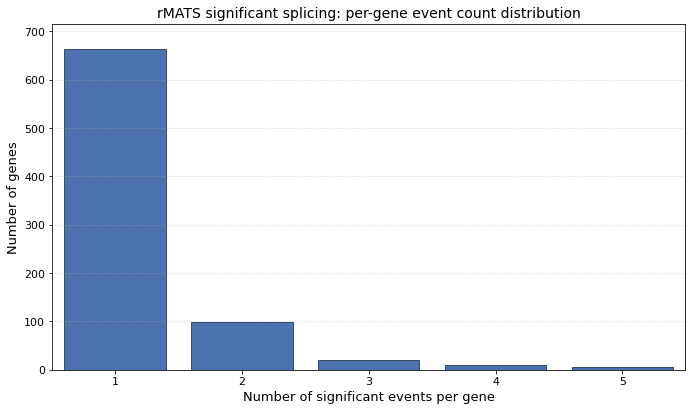

Saved: /path/to/rMATS/output/rmats_summary/rmats_num_events_per_gene_distribution.png
Saved: /path/to/rMATS/output/rmats_summary/rmats_num_events_per_gene_distribution.svg
Saved: /path/to/rMATS/output/rmats_summary/rmats_num_events_per_gene_distribution.pdf
Example: 99  genes each have exactly 2 events.

Genes with >3 significant events (gene_name, gene_id, num_events):
gene_name             gene_id  num_events
     TCN2  ENSSSCG00000010011           5
           ENSSSCG00000036350           5
   TCF7L2  ENSSSCG00000010638           5
   CCDC18  ENSSSCG00000006897           5
  NUP210L  ENSSSCG00000038125           5
           ENSSSCG00000033421           4
     BRD1  ENSSSCG00000032820           4
           ENSSSCG00000023426           4
    TEAD1  ENSSSCG00000013399           4
    RAB9A  ENSSSCG00000012123           4
     NFU1  ENSSSCG00000025007           4
           ENSSSCG00000039306           4
   SEC31A  ENSSSCG00000009244           4
   MAP4K4  ENSSSCG00000008164          

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

if 'sig_events' not in globals():
    raise RuntimeError("Please run previous cells to generate sig_events first.")

counts_per_gene = (
    sig_events.groupby(['gene_name', 'gene_id']).size().reset_index(name='num_events')
)

dist = counts_per_gene['num_events'].value_counts().sort_index()
dist_df = dist.reset_index()
dist_df.columns = ['num_events', 'num_genes']

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

dist_tsv = out_dir / 'rmats_num_events_per_gene_distribution.tsv'
dist_df.to_csv(dist_tsv, sep='\t', index=False)
print('Saved:', dist_tsv)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(9.5, 5.6), constrained_layout=True)
xs = dist_df['num_events'].astype(int).tolist()
ys = dist_df['num_genes'].astype(int).tolist()
ax.bar(xs, ys, width=0.8, color='#4C72B0', edgecolor='#1f3349', linewidth=0.8)
ax.set_xlabel('Number of significant events per gene')
ax.set_ylabel('Number of genes')
ax.set_title('rMATS significant splicing: per-gene event count distribution')
ax.set_xticks(xs)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
ax.margins(x=0.02)
if ys:
    ymax = max(ys) * 1.08
    ax.set_ylim(0, ymax)

fig.canvas.draw_idle()

fig_png = out_dir / 'rmats_num_events_per_gene_distribution.png'
fig_svg = out_dir / 'rmats_num_events_per_gene_distribution.svg'
fig_pdf = out_dir / 'rmats_num_events_per_gene_distribution.pdf'
fig.savefig(fig_png, dpi=300, facecolor='white')
fig.savefig(fig_svg, facecolor='white')
fig.savefig(fig_pdf, facecolor='white')
plt.show()
print('Saved:', fig_png)
print('Saved:', fig_svg)
print('Saved:', fig_pdf)

example = dist_df[dist_df['num_events'] == 2]
if not example.empty:
    print(f"Example: {int(example['num_genes'].iloc[0])} genes each have exactly 2 events.")
else:
    print("Example: no gene has exactly 2 events.")

more_than_3 = counts_per_gene[counts_per_gene['num_events'] >= 3] \
    .sort_values('num_events', ascending=False) \
    .reset_index(drop=True)
print("\nGenes with >3 significant events (gene_name, gene_id, num_events):")
if more_than_3.empty:
    print("None")
else:
    print(more_than_3.to_string(index=False))

out_top = out_dir / 'rmats_genes_with_more_than_3_events.tsv'
more_than_3.to_csv(out_top, sep='\t', index=False)
print('Saved:', out_top)


In [ ]:
# DDX39B is absent because the current thresholds are FDR <= 0.05 and |dPSI| >= 0.1. Although DDX39B has significant FDR events in rMATS JCEC (e.g. A3SS/RI/A5SS), its dPSI is ~0.05-0.07, below 0.1, so it was filtered out.
# To include it, lower DELTA_PSI_THRESHOLD (e.g. to 0.05) and rerun.


Saved: /path/to/rMATS/output/rmats_summary/rmats_event_type_counts.tsv


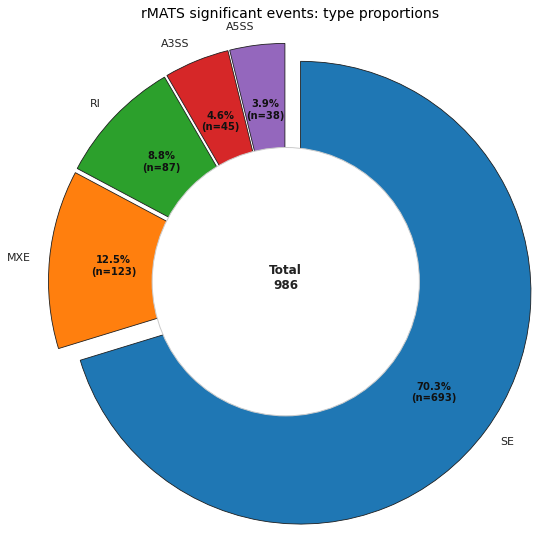

Saved: /path/to/rMATS/output/rmats_summary/rmats_event_type_pie.png
Saved: /path/to/rMATS/output/rmats_summary/rmats_event_type_pie.svg
Saved: /path/to/rMATS/output/rmats_summary/rmats_event_type_pie.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_event_type_pie(sig_df: pd.DataFrame, output_dir: str):
    if sig_df is None or sig_df.empty:
        raise ValueError("sig_events is empty, cannot plot pie chart.")
    if 'event_type' not in sig_df.columns:
        raise ValueError("sig_events missing column 'event_type'")

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    counts = (sig_df['event_type']
              .fillna('NA')
              .value_counts(dropna=False)
              .sort_values(ascending=False)
              .rename_axis('event_type')
              .reset_index(name='count'))
    total = int(counts['count'].sum())
    counts['percent'] = (counts['count'] / total * 100.0).round(2)

    tsv_path = out_dir / 'rmats_event_type_counts.tsv'
    counts.to_csv(tsv_path, sep='\t', index=False)
    print('Saved:', tsv_path)

    sizes = counts['count'].tolist()
    types = counts['event_type'].astype(str).tolist()

    base_cmap = plt.get_cmap('tab20')
    colors = [base_cmap(i) for i in range(0, 2 * len(sizes), 2)]

    explode = [0.03] * len(sizes)
    if sizes:
        max_idx = int(max(range(len(sizes)), key=lambda i: sizes[i]))
        explode[max_idx] = 0.08

    total_n = sum(sizes)
    def autopct_fmt(pct):
        if pct < 0.5:
            return ''
        n = int(round(pct * total_n / 100.0))
        return f"{pct:.1f}%\n(n={n})"

    plt.rcParams.update({
        'font.size': 11,
        'axes.titlesize': 14,
    })
    fig, ax = plt.subplots(figsize=(7.6, 7.6), constrained_layout=True)

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=types,
        startangle=90,
        counterclock=False,
        colors=colors,
        explode=explode,
        shadow=True,
        labeldistance=1.08,
        pctdistance=0.72,
        autopct=autopct_fmt,
        wedgeprops=dict(edgecolor='#1a1a1a', linewidth=0.8, antialiased=True),
        textprops=dict(color='#222')
    )

    centre = plt.Circle((0, 0), 0.58, fc='white', ec='#cccccc', lw=1.0)
    ax.add_artist(centre)

    ax.text(0, 0.02, f"Total\n{total_n}", ha='center', va='center', fontsize=12, weight='bold', color='#222')

    for t in autotexts:
        t.set_color('#111')
        t.set_fontsize(10)
        t.set_weight('bold')

    ax.axis('equal')
    ax.set_title('rMATS significant events: type proportions')

    png = out_dir / 'rmats_event_type_pie.png'
    svg = out_dir / 'rmats_event_type_pie.svg'
    pdf = out_dir / 'rmats_event_type_pie.pdf'
    fig.savefig(png, dpi=320, facecolor='white')
    fig.savefig(svg, facecolor='white')
    fig.savefig(pdf, facecolor='white')
    plt.show()
    print('Saved:', png)
    print('Saved:', svg)
    print('Saved:', pdf)

plot_event_type_pie(sig_events, OUTPUT_DIR)
